<a href="https://colab.research.google.com/github/Ariely13/Tugas/blob/main/Tugas_Praktikum_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import semua library yang dibutuhkan untuk analisis regresi
import pandas as pd                          # untuk manipulasi data
import numpy as np                           # untuk operasi numerik
import matplotlib.pyplot as plt              # untuk visualisasi grafik
import seaborn as sns                        # untuk correlation plot yang lebih indah
import statsmodels.api as sm                 # untuk model regresi & uji statistik
from statsmodels.stats.outliers_influence import variance_inflation_factor  # untuk uji multikolinearitas
from statsmodels.stats.stattools import durbin_watson                        # untuk uji autokorelasi
from scipy import stats                      # untuk uji normalitas
import warnings
warnings.filterwarnings('ignore')

In [8]:
import pandas as pd
data = pd.read_csv("/content/data_iklim - Sheet1.csv")

print(data.head())
print(data.columns)

  precipitation max temperature min temperature         wind  \
0   22,17864727          22,579          16,226   0,98477418   
1   10,77861942          29,369         20,2985  1,054619598   
2   9,443091888          27,384           18,62  0,999835774   
3   15,51303961         21,7585         14,9085  0,922273123   
4   15,21262902          24,568          17,651  1,078517568   

  relative humidity        solar  
0       0,949216707  12,98674041  
1       0,837694214  20,63957504  
2       0,869631027  18,48553254  
3        0,95195662  9,497525996  
4       0,927156092  15,35485704  
Index(['precipitation', 'max temperature', 'min temperature', 'wind',
       'relative humidity', 'solar'],
      dtype='object')


### 1. Mengubah Nama Variabel

In [ ]:
df = df.rename(columns={
    'precipitation'     : 'Y',   # variabel dependen (curah hujan)
    'max temperature'   : 'X1',  # suhu maksimum
    'min temperature'   : 'X2',  # suhu minimum
    'wind'              : 'X3',  # kecepatan angin
    'relative humidity' : 'X4',  # kelembaban relatif
    'solar'             : 'X5'   # radiasi matahari
})
print(df.head())

             Y       X1       X2           X3           X4           X5
0  22,17864727   22,579   16,226   0,98477418  0,949216707  12,98674041
1  10,77861942   29,369  20,2985  1,054619598  0,837694214  20,63957504
2  9,443091888   27,384    18,62  0,999835774  0,869631027  18,48553254
3  15,51303961  21,7585  14,9085  0,922273123   0,95195662  9,497525996
4  15,21262902   24,568   17,651  1,078517568  0,927156092  15,35485704


### 2. Membuat Correlation Plot dan interpretasikan

Matriks Korelasi:


,Y,X1,X2,X3,X4,X5
Y,1.000000,-0.752439,-0.602791,-0.338976,0.640560,-0.636573
X1,-0.752439,1.000000,0.797165,0.449202,-0.736253,0.909192
X2,-0.602791,0.797165,1.000000,0.835801,-0.952236,0.878219
X3,-0.338976,0.449202,0.835801,1.000000,-0.760450,0.665849
X4,0.640560,-0.736253,-0.952236,-0.760450,1.000000,-0.778746
X5,-0.636573,0.909192,0.878219,0.665849,-0.778746,1.000000


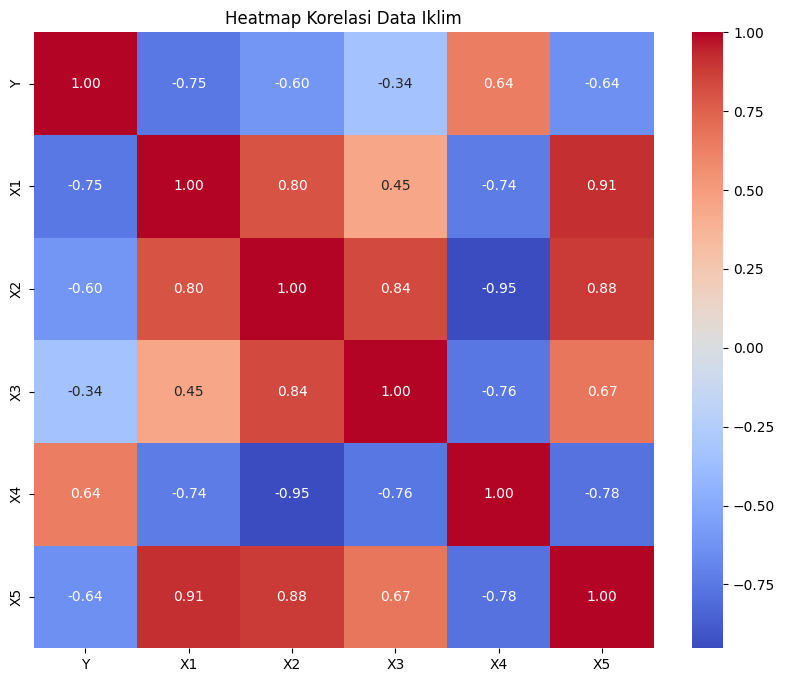

In [ ]:
# mengubah koma menjadi titik dan konversi ke float
# Kita gunakan .str.replace agar koma hilang, lalu pd.to_numeric untuk jadi angka
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

#Menghitung matriks korelasi
correlation_matrix = df.corr()
print("Matriks Korelasi:")
display(correlation_matrix)

#Membuat Visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Data Iklim')
plt.show()

##Interpretasi Correlation Plot

Relative humidity (X4) memiliki hubungan positif kuat dengan curah hujan.

Max temperature (X1) memiliki hubungan negatif kuat dengan curah hujan.

Wind (X3) memiliki pengaruh paling kecil terhadap curah hujan.

Terdapat multikolinearitas tinggi antar beberapa variabel X, terutama X2, X4, dan X5, sehingga perlu diperhatikan saat membuat model regresi.

###3. Membuat Model Regresi Berganda

In [ ]:
# Membangun model regresi linear berganda: Y = b0 + b1X1 + b2X2 + ... + b5X5
# sm.add_constant() menambahkan intersep (konstanta b0) ke model

X = df[['X1', 'X2', 'X3', 'X4', 'X5']]
Y = df['Y']

X_const = sm.add_constant(X)   # tambahkan kolom konstanta
model = sm.OLS(Y, X_const).fit()  # OLS = Ordinary Least Squares (metode kuadrat terkecil)

# Tampilkan ringkasan lengkap model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     27.72
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.55e-15
Time:                        15:44:24   Log-Likelihood:                -164.19
No. Observations:                  78   AIC:                             340.4
Df Residuals:                      72   BIC:                             354.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.9870     16.485     -0.545      0.5

Hasil **OLS Regression** menunjukkan bahwa **model regresi signifikan (F-statistic = 27.72, p-value sangat kecil)** dengan kemampuan menjelaskan sekitar **65,8% variasi Y (R² = 0,658)**, di mana **X1, X2, dan X4 berpengaruh signifikan terhadap Y**, sedangkan **X3 dan X5 tidak signifikan**.


###4. Uji Simultan (Uji F)

In [ ]:
# Uji F menguji apakah SEMUA variabel X secara bersama-sama berpengaruh signifikan terhadap Y
# H0: semua koefisien = 0 (model tidak signifikan)
# H1: minimal satu koefisien ≠ 0 (model signifikan)
# Tolak H0 jika p-value < 0.05

f_statistic = model.fvalue
f_pvalue    = model.f_pvalue

print("=== UJI SIMULTAN (Uji F) ===")
print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {f_pvalue:.4f}")



=== UJI SIMULTAN (Uji F) ===
F-statistic : 27.7204
P-value     : 0.0000


Hasil **uji F simultan** menunjukkan bahwa **model regresi secara keseluruhan signifikan (p-value = 0.0000 < 0.05)**, sehingga **minimal satu variabel independen (X) berpengaruh terhadap variabel dependen (Y)**.


###5. Uji Parsial (Uji T)

In [ ]:
# Uji T menguji pengaruh MASING-MASING variabel X secara individu terhadap Y
# H0: koefisien variabel = 0 (tidak berpengaruh)
# H1: koefisien variabel ≠ 0 (berpengaruh signifikan)
# Tolak H0 jika p-value < 0.05

print("=== UJI PARSIAL (Uji T) ===")
print(f"{'Variabel':<10} {'Koefisien':>12} {'t-statistic':>12} {'p-value':>10} {'Signifikan?':>12}")
print("-" * 60)

for var in X_const.columns:
    coef   = model.params[var]
    t_val  = model.tvalues[var]
    p_val  = model.pvalues[var]
    sig    = "✔ Ya" if p_val < 0.05 else "✘ Tidak"
    print(f"{var:<10} {coef:>12.4f} {t_val:>12.4f} {p_val:>10.4f} {sig:>12}")

=== UJI PARSIAL (Uji T) ===
Variabel      Koefisien  t-statistic    p-value  Signifikan?
------------------------------------------------------------
const           -8.9870      -0.5452     0.5873      ✘ Tidak
X1              -1.5501      -4.8853     0.0000         ✔ Ya
X2               1.0764       3.0330     0.0034         ✔ Ya
X3              -0.8865      -1.7789     0.0795      ✘ Tidak
X4              46.4389       3.7439     0.0004         ✔ Ya
X5               0.1568       0.9064     0.3677      ✘ Tidak


Hasil uji t parsial menunjukkan bahwa variabel X1, X2, dan X4 berpengaruh signifikan terhadap model (p-value < 0,05), sedangkan const, X3, dan X5 tidak signifikan karena memiliki p-value > 0,05.

###6. Koefisien Determinasi (R²)

In [ ]:
# R² mengukur seberapa besar variasi Y yang dapat dijelaskan oleh variabel X
# Nilai R² berkisar 0–1, semakin mendekati 1 semakin baik model

r_squared     = model.rsquared
adj_r_squared = model.rsquared_adj

print("=== KOEFISIEN DETERMINASI ===")
print(f"R²          : {r_squared:.4f}  →  model menjelaskan {r_squared*100:.2f}% variasi Y")
print(f"Adjusted R² : {adj_r_squared:.4f}  →  R² yang sudah disesuaikan jumlah variabel")

=== KOEFISIEN DETERMINASI ===
R²          : 0.6581  →  model menjelaskan 65.81% variasi Y
Adjusted R² : 0.6344  →  R² yang sudah disesuaikan jumlah variabel


Nilai **R² = 0,6581** menunjukkan bahwa **model mampu menjelaskan 65,81% variasi pada variabel Y**, sedangkan **Adjusted R² = 0,6344** menunjukkan bahwa setelah disesuaikan dengan jumlah variabel, model menjelaskan **63,44% variasi Y**.


###7. Cek 4 Asumsi Regresi

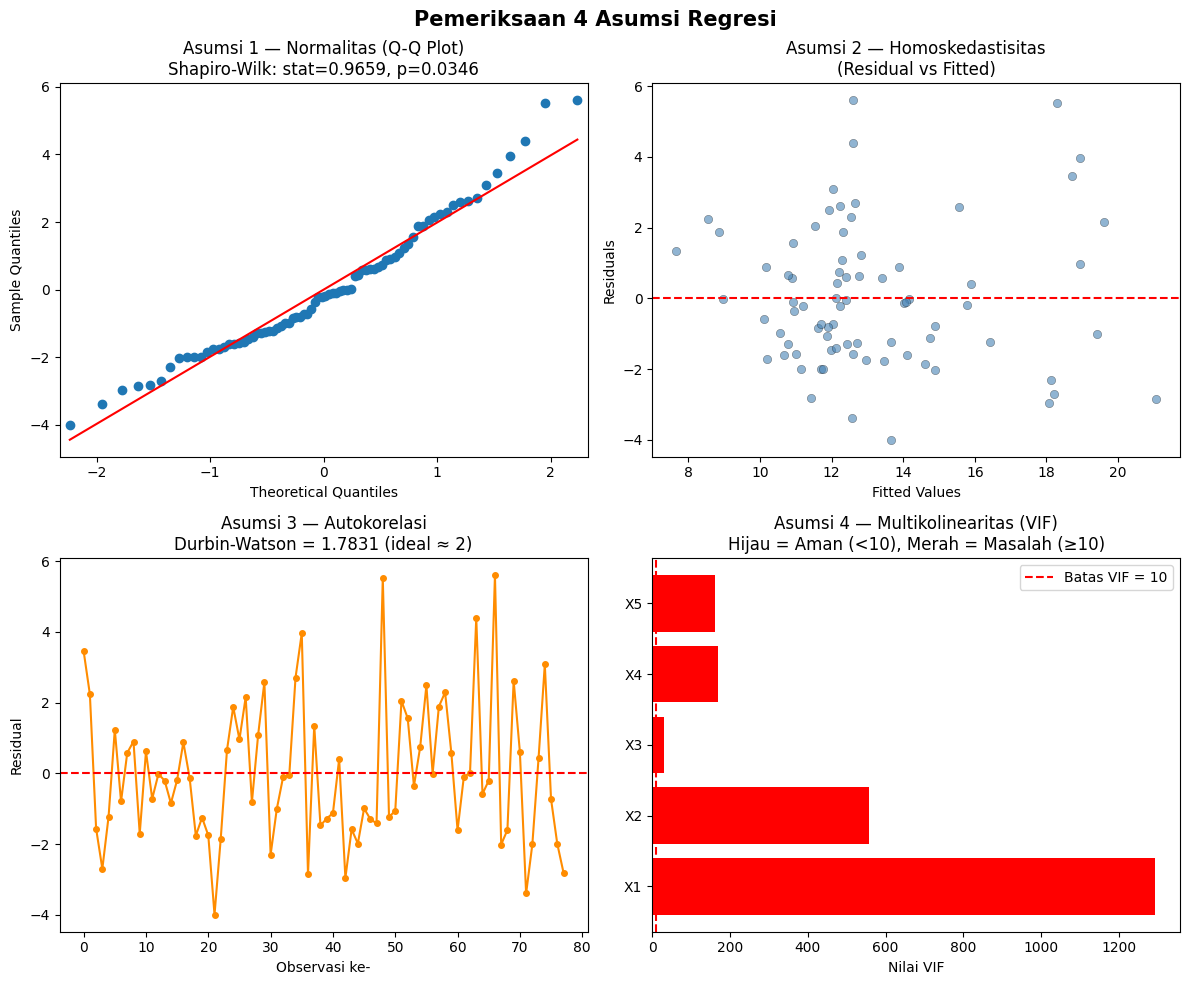

In [ ]:
residuals    = model.resid          # nilai sisa (error) dari model
fitted_vals  = model.fittedvalues   # nilai Y yang diprediksi model

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Pemeriksaan 4 Asumsi Regresi', fontsize=15, fontweight='bold')

# ── ASUMSI 1: NORMALITAS RESIDUAL ─────────────────────────────────────────────
# Residual harus berdistribusi normal agar estimasi koefisien valid
# Uji: Shapiro-Wilk → H0: residual normal, tolak H0 jika p < 0.05
stat_sw, p_sw = stats.shapiro(residuals)
sm.qqplot(residuals, line='s', ax=axes[0, 0])
axes[0, 0].set_title(f'Asumsi 1 — Normalitas (Q-Q Plot)\nShapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f}')

# ── ASUMSI 2: HOMOSKEDASTISITAS ────────────────────────────────────────────────
# Varians residual harus KONSTAN (tidak membentuk pola corong/melebar)
# Jika ada pola, terjadi heteroskedastisitas → model tidak efisien
axes[0, 1].scatter(fitted_vals, residuals, alpha=0.6, color='steelblue', edgecolors='black', linewidths=0.3)
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Asumsi 2 — Homoskedastisitas\n(Residual vs Fitted)')

# ── ASUMSI 3: AUTOKORELASI ─────────────────────────────────────────────────────
# Residual tidak boleh saling berkorelasi satu sama lain
# Uji: Durbin-Watson → nilai mendekati 2 = tidak ada autokorelasi
#   nilai < 1.5 = autokorelasi positif, nilai > 2.5 = autokorelasi negatif
dw_stat = durbin_watson(residuals)
axes[1, 0].plot(residuals.values, marker='o', linestyle='-', color='darkorange', markersize=4)
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Observasi ke-')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title(f'Asumsi 3 — Autokorelasi\nDurbin-Watson = {dw_stat:.4f} (ideal ≈ 2)')

# ── ASUMSI 4: MULTIKOLINEARITAS ────────────────────────────────────────────────
# Variabel X tidak boleh saling berkorelasi terlalu tinggi
# Uji: VIF (Variance Inflation Factor) → VIF < 10 = tidak ada multikolinearitas
vif_data = pd.DataFrame()
vif_data['Variabel'] = X.columns
vif_data['VIF']      = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

axes[1, 1].barh(vif_data['Variabel'], vif_data['VIF'], color=['green' if v < 10 else 'red' for v in vif_data['VIF']])
axes[1, 1].axvline(x=10, color='red', linestyle='--', label='Batas VIF = 10')
axes[1, 1].set_xlabel('Nilai VIF')
axes[1, 1].set_title('Asumsi 4 — Multikolinearitas (VIF)\nHijau = Aman (<10), Merah = Masalah (≥10)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


1.Asumsi Normalitas (Q-Q Plot dan Shapiro-Wilk)Nilai Shapiro-Wilk = 0.9659 dengan p-value = 0.0346.

Interpretasi:
Pada Q-Q Plot, titik-titik residual sebagian besar mengikuti garis diagonal, tetapi ada sedikit penyimpangan di bagian ujung.

Nilai p-value < 0.05, sehingga secara statistik residual tidak sepenuhnya berdistribusi normal.

2.Asumsi Homoskedastisitas (Residual vs Fitted)

Pada grafik Residual vs Fitted terlihat:
Titik residual menyebar di sekitar garis nol.Tidak membentuk pola tertentu (seperti pola kipas atau kurva).

3.Asumsi Autokorelasi (Durbin-Watson)

Nilai Durbin-Watson = 1.7831

Interpretasi:Nilai ideal Durbin-Watson adalah sekitar 2.Nilai 1.78 mendekati 2 sehingga menunjukkan tidak ada autokorelasi yang serius pada residual.

4.Asumsi Autokorelasi (Durbin-Watson)

Nilai Durbin-Watson = 1.7831

Interpretasi:Nilai ideal Durbin-Watson adalah sekitar 2.Nilai 1.78 mendekati 2, sehingga menunjukkan tidak ada autokorelasi yang serius pada residual.
